# Partie 5 (ML Supervise)

L’objectif de ce notebook est de compléter les valeurs manquantes du dataset afin de pouvoir prioriser les vulnérabilités. Nous cherchons d’abord à prédire les valeurs CVSS manquantes, puis les valeurs EPSS manquantes. Le CVSS représente la gravité technique d’une vulnérabilité, tandis que l’EPSS représente sa probabilité d’exploitation.

Nous avons prepare et encode les donnees de differentes manieres en fonction de leur type. Les variables catégorielles comme l’éditeur, le produit, le type ou le CWE sont transformées avec un OneHotEncoder plutot qu'avec un LabelEncoder pour eviter d'influencer les modeles par le code des labels. Les colonnes textuelles comme le titre, la description CVE et la description CWE sont transformées avec un TF-IDF, ce qui permet de représenter les mots importants sous forme numérique. Nous ne pouvons pas conserver tous les mots car cela ferait trop de donnees donc on decide de conserver seulement 500 mots.

Les dates sont également transformées en variables simples, comme l’année et le mois, pour conserver une information temporelle exploitable par le modèle. Les valeurs EPSS manquantes sont temporairement remplacées par la médiane afin de pouvoir utiliser cette variable comme information d’entrée.

Pour rendre le modèle CVSS plus réaliste, nous retirons certaines colonnes directement liées au calcul du score, comme Base Severity, Attack Vector ou les impacts confidentialité / intégrité / disponibilité. Cela permet d’éviter une fuite d’information et de ne pas surestimer les performances du modèle.

Pour l’EPSS, nous utilisons également un modèle de régression, car l’EPSS est une valeur numérique comprise entre 0 et 1.

Enfin, une fois les valeurs CVSS et EPSS complétées, un score de risque est calculé en combinant les deux informations. Le CVSS est pondéré à 60 %, car il représente la gravité technique, et l’EPSS à 40 %, car il représente la probabilité d’exploitation. Ce score permet de classer les vulnérabilités en niveaux de priorité : LOW, MEDIUM, HIGH et CRITICAL.

Le code principal est séparé dans un fichier `utils.py` afin de rendre le notebook plus lisible et de pouvoir réutiliser les fonctions sur de nouvelles données.

### 1) Importations

In [1]:
import utils
import numpy as np
import pandas as pd

print(utils.__file__)
print(dir(utils))

C:\Users\Baptiste\OneDrive - Efrei\Bureau\Baptiste\Efrei\I1\S6 - efrei\ml\Mastercamp\TD_noté\utils.py
['OneHotEncoder', 'TfidfVectorizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'complete_cvss_missing_values', 'complete_epss_missing_values', 'create_completed_dataset', 'create_cvss_train_test_data', 'create_epss_train_test_data', 'create_risk_score', 'evaluate_model', 'get_cvss_columns', 'load_prepare_and_encode_dataset', 'mean_absolute_error', 'mean_squared_error', 'np', 'pd', 'process_new_data', 'r2_score']


In [2]:
from sklearn.ensemble import GradientBoostingRegressor

from utils import (
    load_prepare_and_encode_dataset,
    get_cvss_columns,
    create_cvss_train_test_data,
    evaluate_model,
    complete_cvss_missing_values,
    create_epss_train_test_data,
    complete_epss_missing_values,
    create_completed_dataset,
    process_new_data
)

### 2) Chargement et encodage du dataset

In [3]:
df, dataset_encoded, OneHot_encoder, TfIdf_vectorizer = load_prepare_and_encode_dataset("./data/test.csv")

In [4]:
print("Shape :", dataset_encoded.shape)

print("Valeurs manquantes restantes :")
print(dataset_encoded.isna().sum().sort_values(ascending=False).head(10))

df.head()

Shape : (125372, 7749)
Valeurs manquantes restantes :
CVSS                                                                    96091
EPSS                                                                      763
Type_Alerte                                                                 0
Type_Avis                                                                   0
Editeur_ AMD, AMD, AMD, AMD, AMD, AMD , AMD, AMD, AMD, AMD, AMD, AMD        0
tfidf_warning                                                               0
Editeur_ADOdb                                                               0
Editeur_AMD                                                                 0
Editeur_AMD,  AMD                                                           0
Editeur_AMD, AMD                                                            0
dtype: int64


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description,CVSS,Base Severity,Attack Vector,Attack Complexity,...,Lien solution,Description CWE,Editeur,Produit,Versions affectées,year,month,EPSS_missing,EPSS_filled,text_for_tfidf
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,Unknown,Unknown,Unknown,...,https://psirt.global.sonicwall.com/vuln-detail...,CWE-89: Improper Neutralization of Special Ele...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,2021,2,0,0.79818,|MàJ] Vulnérabilité dans SonicWall SMA100 A SQ...
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,Unknown,Unknown,Unknown,...,http://lists.opensuse.org/opensuse-security-an...,,Unknown,Unknown,NaN,2021,2,0,0.94220,|MàJ] Vulnérabilité dans SonicWall SMA100 GNU ...
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,Unknown,Unknown,Unknown,...,https://lists.fedoraproject.org/archives/list/...,Heap buffer overflow,Google,Chrome,unspecified,2021,2,0,0.19904,[MàJ] Vulnérabilité dans Google Chrome et Micr...
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alerte,2021-02-25,CVE-2021-21972,The vSphere Client (HTML5) contains a remote c...,NaN,Unknown,Unknown,Unknown,...,https://www.vmware.com/security/advisories/VMS...,Remote code execution vulnerability,"n/a, n/a","VMware vCenter Server, VMware Cloud Foundation","7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",2021,2,0,0.93821,[MàJ] Vulnérabilité dans VMware vCenter Server...
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-26858,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...","Microsoft Exchange Server 2019, Microsoft Exc...","15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",2021,3,0,0.55064,[MàJ] Multiples vulnérabilités dans Microsoft ...


### 3) Creation des test/split set pour modele CVSS

In [5]:
cols_to_remove = get_cvss_columns(dataset_encoded)
print("Nombre de colonnes retirées :", len(cols_to_remove))

Nombre de colonnes retirées : 35


In [6]:
X_train_realistic, X_test_realistic, y_train_realistic, y_test_realistic = create_cvss_train_test_data(
    dataset_encoded,
    cols_to_remove
)

In [7]:
print(X_train_realistic.shape)
print(X_test_realistic.shape)
print(y_train_realistic.shape)
print(y_test_realistic.shape)

print("NaN dans X_train :", X_train_realistic.isna().sum().sum())

(23424, 7712)
(5857, 7712)
(23424,)
(5857,)
NaN dans X_train : 0


### 4) Entrainement du meilleur modele cvss

In [8]:
model_cvss_realistic = GradientBoostingRegressor(
    random_state=42,
    subsample=1.0,
    n_estimators=150,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.1
)

model_cvss_realistic.fit(X_train_realistic, y_train_realistic)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


### 5) Evaluation du modele

In [9]:
y_pred_realistic = model_cvss_realistic.predict(X_test_realistic)

evaluate_model(y_test_realistic, y_pred_realistic)

MAE : 0.8642822480152852
RMSE : 1.1687532135490328
R² : 0.5240206729102144


(0.8642822480152852, np.float64(1.1687532135490328), 0.5240206729102144)

In [10]:
y_pred_train = model_cvss_realistic.predict(X_train_realistic)

print("Performances sur le train :")
evaluate_model(y_train_realistic, y_pred_train)

print("Performances sur le test :")
evaluate_model(y_test_realistic, y_pred_realistic)

Performances sur le train :
MAE : 0.8369223021677061
RMSE : 1.1266069961311955
R² : 0.5567154931233649
Performances sur le test :
MAE : 0.8642822480152852
RMSE : 1.1687532135490328
R² : 0.5240206729102144


(0.8642822480152852, np.float64(1.1687532135490328), 0.5240206729102144)

Le modele ne semble pas overfitter

### 6) Completion cvss manquants

In [11]:
df = complete_cvss_missing_values(
    df,
    dataset_encoded,
    model_cvss_realistic,
    cols_to_remove
)

### 7) Sauvegarde des resultats

In [12]:
df.to_csv("./data/dataset_with_cvss_completed.csv", sep=";", index=False)

# B) Prediction des EPSS manquants

### 1) Creation des test/split set pour modele EPSS

In [13]:
X_train_epss, X_test_epss, y_train_epss, y_test_epss = create_epss_train_test_data(
    dataset_encoded,
    df
)

print(X_train_epss.shape)
print(X_test_epss.shape)
print(y_train_epss.shape)
print(y_test_epss.shape)

print("NaN dans X_train_epss :", X_train_epss.isna().sum().sum())

(99687, 7746)
(24922, 7746)
(99687,)
(24922,)
NaN dans X_train_epss : 0


### 2) Entrainement du modele EPSS

In [ ]:
model_epss = GradientBoostingRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    subsample=1.0
)

model_epss.fit(X_train_epss, y_train_epss)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [15]:
y_pred_epss = model_epss.predict(X_test_epss)

evaluate_model(y_test_epss, y_pred_epss)

MAE : 0.016820565317123184
RMSE : 0.0686177656523449
R² : 0.3737621866456955


(0.016820565317123184, np.float64(0.0686177656523449), 0.3737621866456955)

In [16]:
df = complete_epss_missing_values(
    df,
    dataset_encoded,
    model_epss
)

In [17]:
print("EPSS manquants avant :", df["EPSS"].isna().sum())
print("EPSS_completed manquants après :", df["EPSS_completed"].isna().sum())

df[["CVE", "CVSS", "CVSS_completed", "EPSS", "EPSS_completed"]].head(20)

EPSS manquants avant : 763
EPSS_completed manquants après : 0


,CVE,CVSS,CVSS_completed,EPSS,EPSS_completed
0,CVE-2021-20016,NaN,7.880039,0.79818,0.79818
1,CVE-2014-6271,NaN,9.183692,0.94220,0.94220
2,CVE-2021-21148,NaN,7.646241,0.19904,0.19904
3,CVE-2021-21972,NaN,8.858985,0.93821,0.93821
4,CVE-2021-26858,7.8,7.800000,0.55064,0.55064
5,CVE-2021-27078,9.1,9.100000,0.32551,0.32551
6,CVE-2021-26857,7.8,7.800000,0.34542,0.34542
7,CVE-2021-26855,9.1,9.100000,0.94351,0.94351
8,CVE-2021-27065,7.8,7.800000,0.94282,0.94282
9,CVE-2021-26412,9.1,9.100000,0.24204,0.24204


In [18]:
df.to_csv("./data/dataset_with_cvss_and_epss_completed.csv", sep=";", index=False)

### C) Creation du score de risque

In [19]:
df_completed = create_completed_dataset(df)

In [20]:
df_completed[[
    "CVE",
    "CVSS",
    "CVSS_completed",
    "EPSS",
    "EPSS_completed",
    "risk_score",
    "risk_priority"
]].head(20)

,CVE,CVSS,CVSS_completed,EPSS,EPSS_completed,risk_score,risk_priority
0,CVE-2021-20016,NaN,7.880039,0.79818,0.79818,0.792074,HIGH
1,CVE-2014-6271,NaN,9.183692,0.94220,0.94220,0.927902,CRITICAL
2,CVE-2021-21148,NaN,7.646241,0.19904,0.19904,0.538390,MEDIUM
3,CVE-2021-21972,NaN,8.858985,0.93821,0.93821,0.906823,CRITICAL
4,CVE-2021-26858,7.8,7.800000,0.55064,0.55064,0.688256,HIGH
5,CVE-2021-27078,9.1,9.100000,0.32551,0.32551,0.676204,HIGH
6,CVE-2021-26857,7.8,7.800000,0.34542,0.34542,0.606168,HIGH
7,CVE-2021-26855,9.1,9.100000,0.94351,0.94351,0.923404,CRITICAL
8,CVE-2021-27065,7.8,7.800000,0.94282,0.94282,0.845128,CRITICAL
9,CVE-2021-26412,9.1,9.100000,0.24204,0.24204,0.642816,HIGH


In [21]:
df_completed["risk_priority"].value_counts()

risk_priority
MEDIUM      117998
LOW           5593
HIGH          1049
CRITICAL       732
Name: count, dtype: int64

In [27]:
df_completed.groupby("risk_priority")[[
    "CVSS_completed",
    "EPSS_completed",
    "risk_score"
]].mean()

C:\Users\Baptiste\AppData\Local\Temp\ipykernel_27068\4232588133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_completed.groupby("risk_priority")[[


,CVSS_completed,EPSS_completed,risk_score
risk_priority,,,
LOW,3.975023,0.002355,0.239443
MEDIUM,7.378790,0.004120,0.444375
HIGH,8.343468,0.435574,0.674838
CRITICAL,8.396338,0.895878,0.862132


# D) Sauvegarde du dataset final enrichi

In [23]:
df_completed.to_csv("./data/dataset_completed_final.csv", sep=";", index=False)

In [24]:
df_completed.head(20)

,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description,CVSS,Base Severity,Attack Vector,Attack Complexity,...,Versions affectées,year,month,EPSS_missing,EPSS_filled,text_for_tfidf,CVSS_completed,EPSS_completed,risk_score,risk_priority
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,Unknown,Unknown,Unknown,...,SMA100 build version 10.x,2021,2,0,0.79818,|MàJ] Vulnérabilité dans SonicWall SMA100 A SQ...,7.880039,0.79818,0.792074,HIGH
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,Unknown,Unknown,Unknown,...,NaN,2021,2,0,0.94220,|MàJ] Vulnérabilité dans SonicWall SMA100 GNU ...,9.183692,0.94220,0.927902,CRITICAL
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,Unknown,Unknown,Unknown,...,unspecified,2021,2,0,0.19904,[MàJ] Vulnérabilité dans Google Chrome et Micr...,7.646241,0.19904,0.538390,MEDIUM
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alerte,2021-02-25,CVE-2021-21972,The vSphere Client (HTML5) contains a remote c...,NaN,Unknown,Unknown,Unknown,...,"7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",2021,2,0,0.93821,[MàJ] Vulnérabilité dans VMware vCenter Server...,8.858985,0.93821,0.906823,CRITICAL
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-26858,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,"15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",2021,3,0,0.55064,[MàJ] Multiples vulnérabilités dans Microsoft ...,7.800000,0.55064,0.688256,HIGH
5,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-27078,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,"15.01.0, 15.02.0, 15.00.0, 15.02.0, 15.01.0",2021,3,0,0.32551,[MàJ] Multiples vulnérabilités dans Microsoft ...,9.100000,0.32551,0.676204,HIGH
6,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-26857,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",2021,3,0,0.34542,[MàJ] Multiples vulnérabilités dans Microsoft ...,7.800000,0.34542,0.606168,HIGH
7,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-26855,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",2021,3,0,0.94351,[MàJ] Multiples vulnérabilités dans Microsoft ...,9.100000,0.94351,0.923404,CRITICAL
8,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-27065,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,"15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",2021,3,0,0.94282,[MàJ] Multiples vulnérabilités dans Microsoft ...,7.800000,0.94282,0.845128,CRITICAL
9,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03,CVE-2021-26412,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,"15.00.0, 15.02.0, 15.01.0, 15.01.0, 15.02.0",2021,3,0,0.24204,[MàJ] Multiples vulnérabilités dans Microsoft ...,9.100000,0.24204,0.642816,HIGH


# F) Visualisations

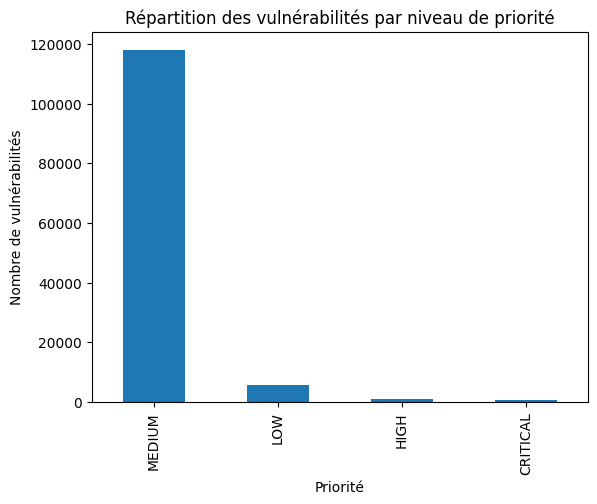

In [26]:
import matplotlib.pyplot as plt

df_completed["risk_priority"].value_counts().plot(kind="bar")

plt.title("Répartition des vulnérabilités par niveau de priorité")
plt.xlabel("Priorité")
plt.ylabel("Nombre de vulnérabilités")
plt.show()

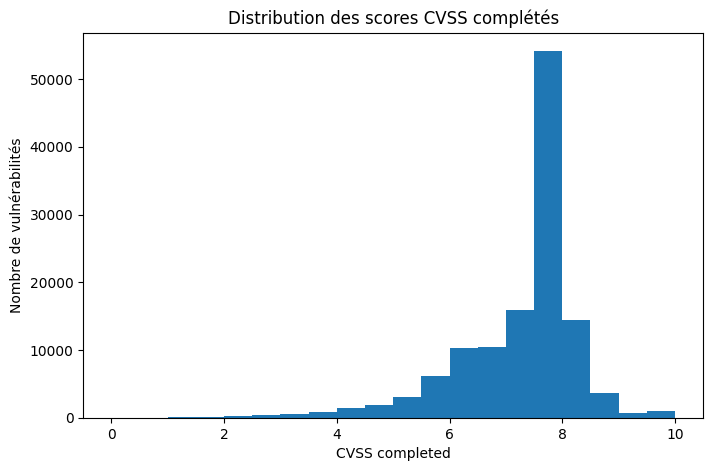

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(df["CVSS_completed"], bins=20)

plt.title("Distribution des scores CVSS complétés")
plt.xlabel("CVSS completed")
plt.ylabel("Nombre de vulnérabilités")
plt.show()

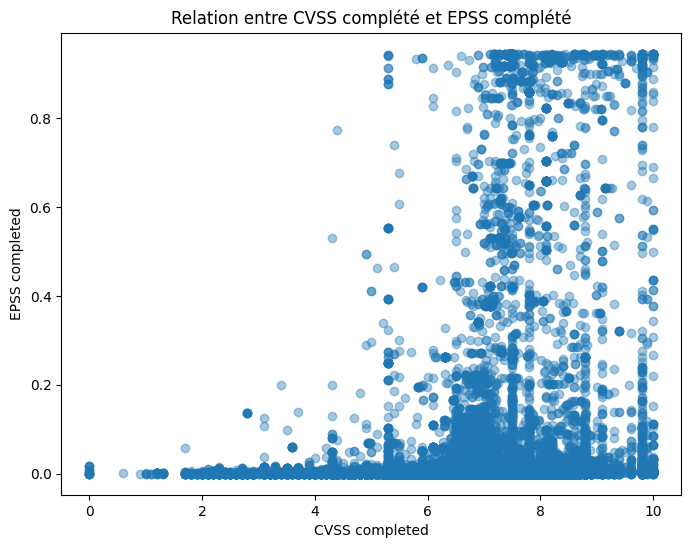

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_completed["CVSS_completed"],
    df_completed["EPSS_completed"],
    alpha=0.4
)

plt.title("Relation entre CVSS complété et EPSS complété")
plt.xlabel("CVSS completed")
plt.ylabel("EPSS completed")
plt.show()